In [1]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


#Loadig dataset

In [2]:
!pip install -q datasets

In [3]:
from datasets import load_dataset

dataset = load_dataset("evilsocket/alucard-sprites")

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['image', 'text'],
        num_rows: 312550
    })
})


In [4]:
print(dataset)
print("\nSplits:", dataset.keys())

for split in dataset:
    print(f"\n{split}:")
    print("Number of samples:", len(dataset[split]))
    print("Features:", dataset[split].features)

DatasetDict({
    train: Dataset({
        features: ['image', 'text'],
        num_rows: 312550
    })
})

Splits: dict_keys(['train'])

train:
Number of samples: 312550
Features: {'image': Image(mode=None, decode=True), 'text': Value('string')}


In [5]:
image = dataset["train"][0]["image"]

print("Type:", type(image))
print("Size:", image.size)
print("Mode:", image.mode)
print("Text:", dataset["train"][0]["text"])

Type: <class 'PIL.PngImagePlugin.PngImageFile'>
Size: (128, 128)
Mode: RGBA
Text: pixel art, gray, small, wizard, mage, spellcaster, back view


Before preprocessing

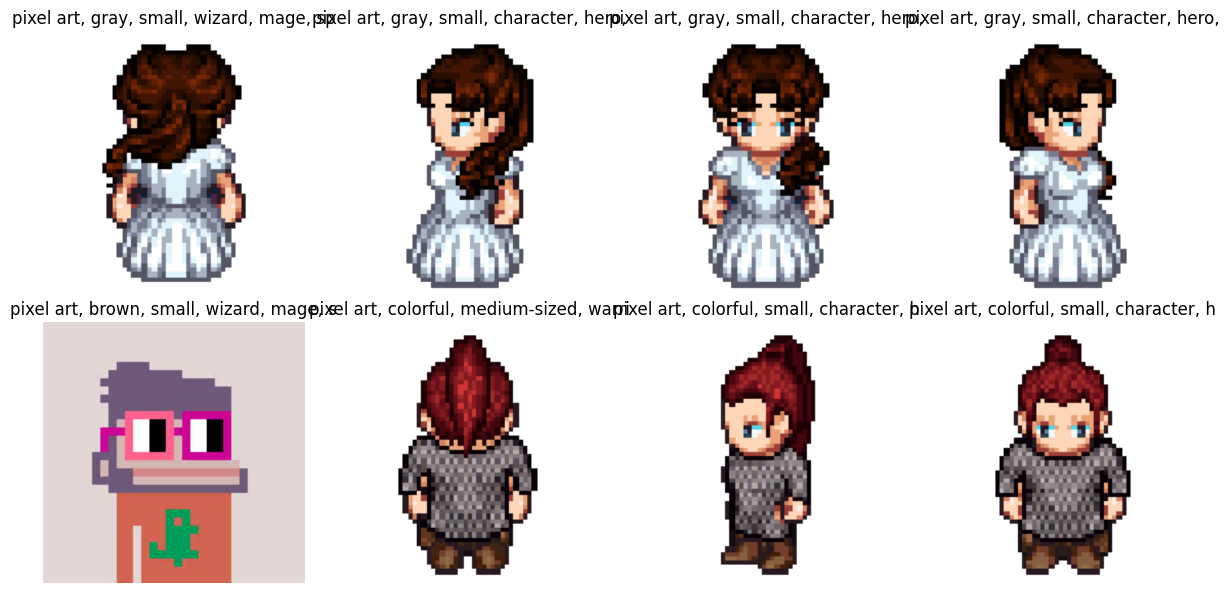

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    image = dataset["train"][i]["image"]
    ax.imshow(image)
    ax.set_title(dataset["train"][i]["text"][:40])
    ax.axis("off")

plt.tight_layout()
plt.show()

we can observe most of sprites contain transparent pixels

In [7]:
import numpy as np

for i in range(8):
    image = dataset["train"][i]["image"]

    alpha = np.array(image.getchannel("A"))

    print(
        f"Image {i}: "
        f"alpha min={alpha.min()}, "
        f"max={alpha.max()}, "
        f"transparent pixels={(alpha == 0).sum()}, "
        f"total pixels={alpha.size}"
    )

Image 0: alpha min=0, max=255, transparent pixels=9923, total pixels=16384
Image 1: alpha min=0, max=255, transparent pixels=10787, total pixels=16384
Image 2: alpha min=0, max=255, transparent pixels=10092, total pixels=16384
Image 3: alpha min=0, max=255, transparent pixels=10681, total pixels=16384
Image 4: alpha min=255, max=255, transparent pixels=0, total pixels=16384
Image 5: alpha min=0, max=255, transparent pixels=10923, total pixels=16384
Image 6: alpha min=0, max=255, transparent pixels=12041, total pixels=16384
Image 7: alpha min=0, max=255, transparent pixels=11078, total pixels=16384


#Preprocessing

##Removing duplicate images to avoid risk of overfitting

In [33]:
import hashlib
import numpy as np

def image_hash(image):
    pixels = np.asarray(
        image.convert("RGBA"),
        dtype=np.uint8
    )
    return hashlib.sha256(pixels.tobytes()).hexdigest()


all_hashes = []
seen_hashes = set()

for i, item in enumerate(dataset["train"]):
    h = image_hash(item["image"])

    if h not in seen_hashes:
        seen_hashes.add(h)
        all_hashes.append(i)

    if (i + 1) % 10_000 == 0:
        print(f"Processed {i + 1:,} images")

print("\nTotal dataset images:", len(dataset["train"]))
print("Unique images:", len(all_hashes))
print("Exact duplicates removed:", len(dataset["train"]) - len(all_hashes))

Processed 10,000 images
Processed 20,000 images
Processed 30,000 images
Processed 40,000 images
Processed 50,000 images
Processed 60,000 images
Processed 70,000 images
Processed 80,000 images
Processed 90,000 images
Processed 100,000 images
Processed 110,000 images
Processed 120,000 images
Processed 130,000 images
Processed 140,000 images
Processed 150,000 images
Processed 160,000 images
Processed 170,000 images
Processed 180,000 images
Processed 190,000 images
Processed 200,000 images
Processed 210,000 images
Processed 220,000 images
Processed 230,000 images
Processed 240,000 images
Processed 250,000 images
Processed 260,000 images
Processed 270,000 images
Processed 280,000 images
Processed 290,000 images
Processed 300,000 images
Processed 310,000 images

Total dataset images: 312550
Unique images: 282511
Exact duplicates removed: 30039


In [34]:
unique_dataset = dataset["train"].select(all_hashes)

print("Original images:", len(dataset["train"]))
print("Unique images:", len(unique_dataset))

Original images: 312550
Unique images: 282511


##Shuffled data

In [35]:
SEED = 42

unique_dataset = unique_dataset.shuffle(
    seed=SEED
)

print("Shuffled unique dataset:", len(unique_dataset))

Shuffled unique dataset: 282511


##Spliting Dataset

In [36]:
TRAIN_SIZE = 9_000
VAL_SIZE = 1_000
TEST_SIZE = 1_000

TOTAL_SIZE = TRAIN_SIZE + VAL_SIZE + TEST_SIZE

clean_dataset = unique_dataset.select(
    range(TOTAL_SIZE)
)

print("Clean dataset:", len(clean_dataset))

Clean dataset: 11000


In [37]:
train_dataset = clean_dataset.select(
    range(0, TRAIN_SIZE)
)

val_dataset = clean_dataset.select(
    range(
        TRAIN_SIZE,
        TRAIN_SIZE + VAL_SIZE
    )
)

test_dataset = clean_dataset.select(
    range(
        TRAIN_SIZE + VAL_SIZE,
        TOTAL_SIZE
    )
)

print("Training:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Training: 9000
Validation: 1000
Test: 1000


In [38]:
train_hashes = get_hashes(train_dataset)
val_hashes = get_hashes(val_dataset)
test_hashes = get_hashes(test_dataset)

print("Train unique:", len(train_hashes))
print("Validation unique:", len(val_hashes))
print("Test unique:", len(test_hashes))

print("\nExact duplicate checks:")
print("Train ∩ Validation:", len(train_hashes & val_hashes))
print("Train ∩ Test:", len(train_hashes & test_hashes))
print("Validation ∩ Test:", len(val_hashes & test_hashes))

Train unique: 9000
Validation unique: 1000
Test unique: 1000

Exact duplicate checks:
Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


data loading error fix

In [39]:
BATCH_SIZE = 32

train_tf = tf.data.Dataset.from_generator(
    lambda: data_generator(train_dataset),
    output_signature=(
        tf.TensorSpec(
            shape=(128, 128, 4),
            dtype=tf.float32
        ),
        tf.TensorSpec(
            shape=(128, 128, 4),
            dtype=tf.float32
        )
    )
)

val_tf = tf.data.Dataset.from_generator(
    lambda: data_generator(val_dataset),
    output_signature=(
        tf.TensorSpec(
            shape=(128, 128, 4),
            dtype=tf.float32
        ),
        tf.TensorSpec(
            shape=(128, 128, 4),
            dtype=tf.float32
        )
    )
)

test_tf = tf.data.Dataset.from_generator(
    lambda: data_generator(test_dataset),
    output_signature=(
        tf.TensorSpec(
            shape=(128, 128, 4),
            dtype=tf.float32
        ),
        tf.TensorSpec(
            shape=(128, 128, 4),
            dtype=tf.float32
        )
    )
)

train_tf = train_tf.batch(BATCH_SIZE).repeat().prefetch(tf.data.AUTOTUNE)
val_tf = val_tf.batch(BATCH_SIZE).repeat().prefetch(tf.data.AUTOTUNE)
test_tf = test_tf.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("Pipelines ready.")

Pipelines ready.


# Autoencoder

In [40]:
encoder = keras.Sequential([
    layers.Input(shape=(128, 128, 4)),

    layers.Conv2D(32, 3, activation="relu",
                  padding="same", strides=2),

    layers.Conv2D(64, 3, activation="relu",
                  padding="same", strides=2),

    layers.Conv2D(128, 3, activation="relu",
                  padding="same", strides=2),

    layers.Conv2D(256, 3, activation="relu",
                  padding="same", strides=2),
], name="encoder")

In [41]:
decoder = keras.Sequential([
    layers.Input(shape=(8, 8, 256)),

    layers.Conv2DTranspose(
        128, 4,
        activation="relu",
        padding="same",
        strides=2
    ),

    layers.Conv2DTranspose(
        64, 4,
        activation="relu",
        padding="same",
        strides=2
    ),

    layers.Conv2DTranspose(
        32, 4,
        activation="relu",
        padding="same",
        strides=2
    ),

    layers.Conv2DTranspose(
        4, 4,
        activation="sigmoid",
        padding="same",
        strides=2
    )
], name="decoder")

In [42]:
autoencoder = keras.Sequential(
    [encoder, decoder],
    name="autoencoder"
)

autoencoder.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse"
)

autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder (Sequential)            │ (None, 8, 8, 256)      │       388,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Sequential)            │ (None, 128, 128, 4)    │       690,404 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,079,108 (4.12 MB)

 Trainable params: 1,079,108 (4.12 MB)

 Non-trainable params: 0 (0.00 B)

#Training

In [43]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True
)
history = autoencoder.fit(
    train_tf,
    steps_per_epoch=282,
    epochs=50,
    validation_data=val_tf,
    validation_steps=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 24s 69ms/step - loss: 0.0436 - val_loss: 0.0153
Epoch 2/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 15s 54ms/step - loss: 0.0121 - val_loss: 0.0110
Epoch 3/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 15s 53ms/step - loss: 0.0100 - val_loss: 0.0096
Epoch 4/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 16s 55ms/step - loss: 0.0088 - val_loss: 0.0110
Epoch 5/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 17s 60ms/step - loss: 0.0079 - val_loss: 0.0080
Epoch 6/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 15s 54ms/step - loss: 0.0080 - val_loss: 0.0066
Epoch 7/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 14s 50ms/step - loss: 0.0063 - val_loss: 0.0060
Epoch 8/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 15s 52ms/step - loss: 0.0058 - val_loss: 0.0056
Epoch 9/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 14s 50ms/step - loss: 0.0055 - val_loss: 0.0052
Epoch 10/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 14s 50ms/step - loss: 0.0053 - val_loss: 0.0049
Epoch 11/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 14s 51ms/step - loss: 0.0049 - val_loss: 0.0047
Epoch 12/50
282/282 ━━━━━━━━━━

In [44]:
test_originals = []
test_reconstructions = []

for images, _ in test_tf:
    reconstructed_batch = autoencoder.predict(
        images,
        verbose=0
    )

    test_originals.append(images.numpy())
    test_reconstructions.append(reconstructed_batch)

test_originals = np.concatenate(test_originals, axis=0)
test_reconstructions = np.concatenate(
    test_reconstructions,
    axis=0
)

print("Test originals:", test_originals.shape)
print("Test reconstructions:", test_reconstructions.shape)

Test originals: (1000, 128, 128, 4)
Test reconstructions: (1000, 128, 128, 4)


#Evaluations

In [45]:
test_mse = np.mean(
    np.square(test_originals - test_reconstructions)
)

print(f"Clean Test MSE: {test_mse:.6f}")

Clean Test MSE: 0.001251


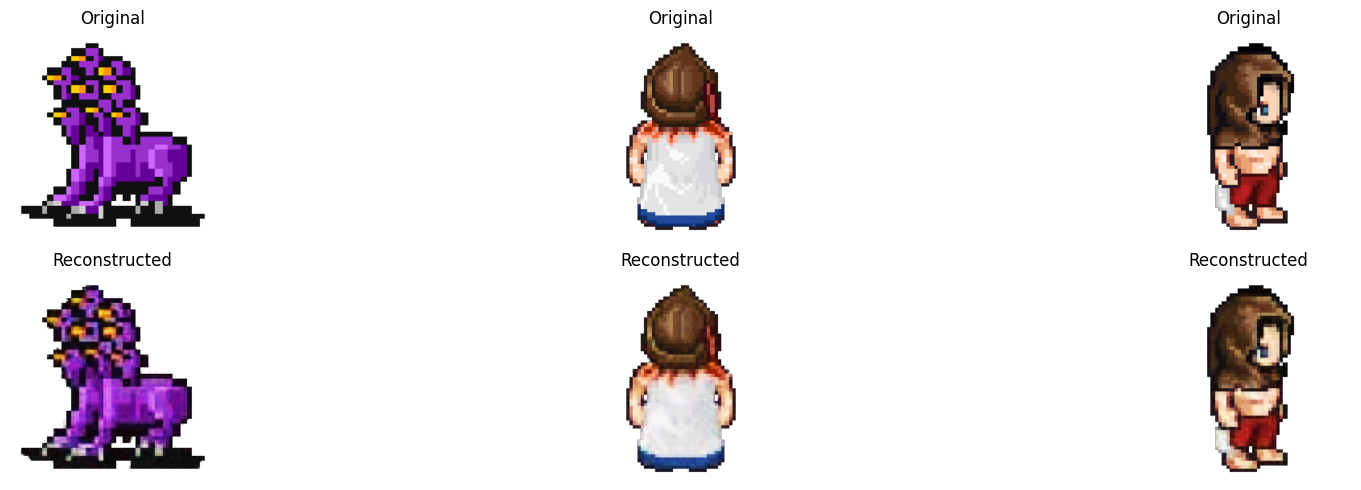

In [67]:
import random
import matplotlib.pyplot as plt

# Randomly select 3 image
random_indices = random.sample(range(len(test_originals)), 3)

fig, axes = plt.subplots(2, 3, figsize=(20, 5))

for i, idx in enumerate(random_indices):

    # Original
    axes[0, i].imshow(test_originals[idx])
    axes[0, i].set_title("Original")
    axes[0, i].axis("off")

    # Reconstruction
    axes[1, i].imshow(test_reconstructions[idx])
    axes[1, i].set_title("Reconstructed")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

-------------------------------------------------------------------------

##training and validation

In [54]:
train_loss = history.history["loss"]
val_loss = history.history["val_loss"]

print("Number of epochs trained:", len(train_loss))
print("Final training loss:", train_loss[-1])
print("Final validation loss:", val_loss[-1])
best_epoch = np.argmin(val_loss) + 1
best_val_loss = val_loss[best_epoch - 1]
best_train_loss = train_loss[best_epoch - 1]

print("Best epoch:", best_epoch)
print(f"Best training loss:   {best_train_loss:.6f}")
print(f"Best validation loss: {best_val_loss:.6f}")

final_train_loss = train_loss[-1]
final_val_loss = val_loss[-1]

absolute_gap = abs(final_val_loss - final_train_loss)
relative_gap = absolute_gap / final_train_loss * 100

print(f"Final training loss:   {final_train_loss:.6f}")
print(f"Final validation loss: {final_val_loss:.6f}")
print(f"Absolute gap:          {absolute_gap:.6f}")
print(f"Relative gap:          {relative_gap:.2f}%")

initial_val_loss = val_loss[0]
best_val_loss = min(val_loss)

improvement = (
    (initial_val_loss - best_val_loss)
    / initial_val_loss
) * 100

print(f"Initial validation loss: {initial_val_loss:.6f}")
print(f"Best validation loss:    {best_val_loss:.6f}")
print(f"Validation improvement:  {improvement:.2f}%")

Number of epochs trained: 50
Final training loss: 0.001815255731344223
Final validation loss: 0.001438433420844376
Best epoch: 49
Best training loss:   0.001411
Best validation loss: 0.001399
Final training loss:   0.001815
Final validation loss: 0.001438
Absolute gap:          0.000377
Relative gap:          20.76%
Initial validation loss: 0.015308
Best validation loss:    0.001399
Validation improvement:  90.86%


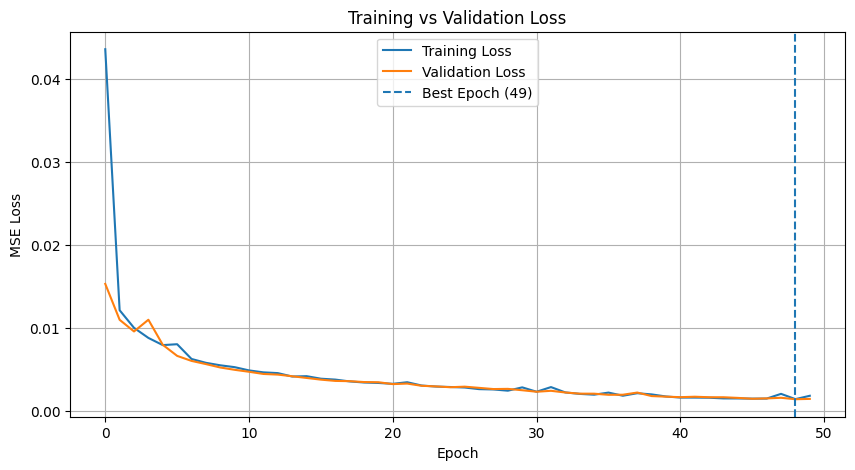

In [51]:
plt.figure(figsize=(10, 5))

plt.plot(train_loss, label="Training Loss")
plt.plot(val_loss, label="Validation Loss")

plt.axvline(
    best_epoch - 1,
    linestyle="--",
    label=f"Best Epoch ({best_epoch})"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

In [55]:
print("Last 10 epochs:\n")

start = max(0, len(train_loss) - 10)

for i in range(start, len(train_loss)):
    print(
        f"Epoch {i + 1:2d}: "
        f"train={train_loss[i]:.6f}, "
        f"val={val_loss[i]:.6f}"
    )

Last 10 epochs:

Epoch 41: train=0.001598, val=0.001646
Epoch 42: train=0.001595, val=0.001701
Epoch 43: train=0.001579, val=0.001638
Epoch 44: train=0.001497, val=0.001636
Epoch 45: train=0.001492, val=0.001558
Epoch 46: train=0.001470, val=0.001456
Epoch 47: train=0.001476, val=0.001497
Epoch 48: train=0.002047, val=0.001572
Epoch 49: train=0.001411, val=0.001399
Epoch 50: train=0.001815, val=0.001438


## Final test-set evaluation

In [56]:
test_mse = np.mean(
    np.square(test_originals - test_reconstructions)
)

print(f"Test MSE: {test_mse:.6f}")

Test MSE: 0.001251


In [57]:
test_mae = np.mean(
    np.abs(test_originals - test_reconstructions)
)

print(f"Test MAE: {test_mae:.6f}")

Test MAE: 0.013435


## Image Reconstruction Quality PSNR and SSIM

In [58]:
psnr_values = tf.image.psnr(
    test_originals,
    test_reconstructions,
    max_val=1.0
).numpy()

mean_psnr = np.mean(psnr_values)

print(f"Mean Test PSNR: {mean_psnr:.2f} dB")

Mean Test PSNR: 29.82 dB


In [59]:
ssim_values = tf.image.ssim(
    test_originals[:, :, :, :3],
    test_reconstructions[:, :, :, :3],
    max_val=1.0
).numpy()

mean_ssim = np.mean(ssim_values)

print(f"Mean Test SSIM: {mean_ssim:.4f}")

Mean Test SSIM: 0.9188


## Unseen evaluation

In [62]:
threshold = 0.05

pixel_errors = np.abs(
    test_originals - test_reconstructions
)

pixel_similarity = np.mean(
    pixel_errors <= threshold
) * 100

print(
    f"Pixel similarity within ±{threshold}: "
    f"{pixel_similarity:.2f}%"
)
results = {
    "Test MSE": test_mse,
    "Test MAE": test_mae,
    "Mean PSNR (dB)": mean_psnr,
    "Mean SSIM": mean_ssim,
    "Pixel Similarity (%)": pixel_similarity
}

for metric, value in results.items():
    print(f"{metric}: {value:.6f}")

Pixel similarity within ±0.05: 91.69%
Test MSE: 0.001251
Test MAE: 0.013435
Mean PSNR (dB): 29.823593
Mean SSIM: 0.918754
Pixel Similarity (%): 91.687730


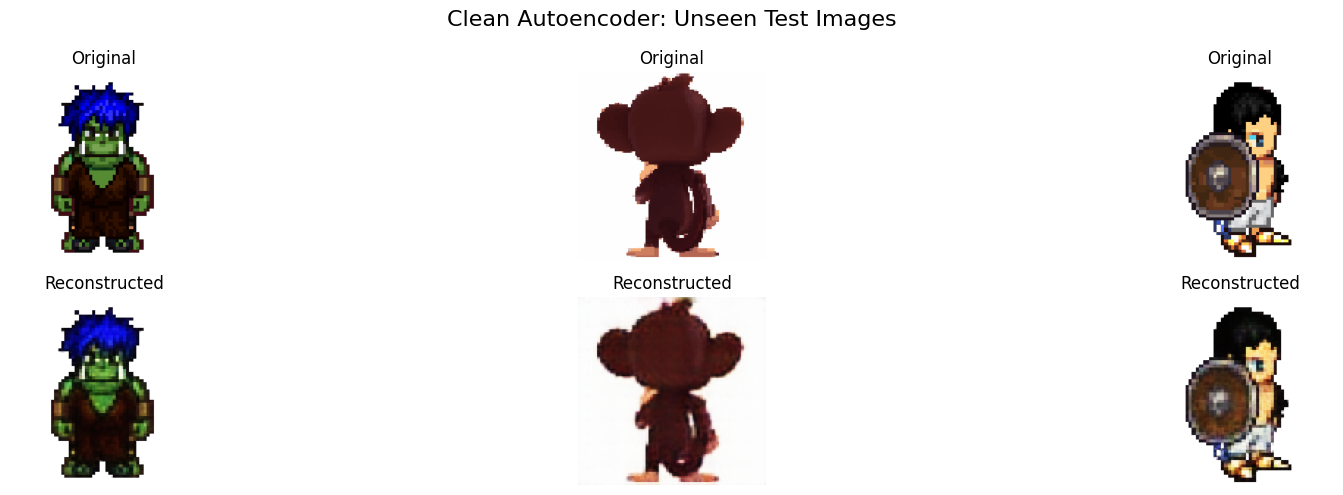

In [66]:
random_indices = random.sample(
    range(len(test_originals)),
    3
)

fig, axes = plt.subplots(
    2, 3,
    figsize=(20, 5)
)

for i, idx in enumerate(random_indices):

    axes[0, i].imshow(test_originals[idx])
    axes[0, i].set_title("Original")
    axes[0, i].axis("off")

    axes[1, i].imshow(test_reconstructions[idx])
    axes[1, i].set_title("Reconstructed")
    axes[1, i].axis("off")

plt.suptitle(
    "Clean Autoencoder: Unseen Test Images",
    fontsize=16
)

plt.tight_layout()
plt.show()